In [1]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import timm
import matplotlib.pyplot as plt
import random
import shutil
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFilter, ImageEnhance
from tqdm import tqdm
from scipy import ndimage

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {device}")
print(f"✅ GPU    : {torch.cuda.get_device_name(0)}")

BASE_DIR = "E:/document_forensics/module5_aidetection/module5a_aidoc"
folders  = [
    "dataset/real",
    "dataset/ai_generated",
    "dataset/train/real",
    "dataset/train/ai_generated",
    "dataset/val/real",
    "dataset/val/ai_generated",
    "dataset/test/real",
    "dataset/test/ai_generated",
    "models",
    "results"
]
for f in folders:
    os.makedirs(os.path.join(BASE_DIR, f), exist_ok=True)

print("✅ Folders created!")

✅ Device : cuda
✅ GPU    : NVIDIA GeForce RTX 4070 Ti SUPER
✅ Folders created!


In [2]:
import os, shutil, random
from tqdm import tqdm

RVL_CDIP_ROOT = "E:/RVL-CDIP"
IMAGE_ROOT    = os.path.join(RVL_CDIP_ROOT, "image_jpg")
BASE_DIR      = "E:/document_forensics/module5_aidetection/module5a_aidoc"
REAL_DIR      = f"{BASE_DIR}/dataset/real"

# Read all entries
entries = []
for label_file in ["train.txt", "val.txt", "test.txt"]:
    with open(os.path.join(RVL_CDIP_ROOT, "labels", label_file), "r") as f:
        for line in f:
            line = line.strip()
            if line:
                entries.append(line.split()[0])

print(f"📋 Total available: {len(entries):,}")

# Use 100,000 images
random.shuffle(entries)
selected = entries[:100000]

copied, failed = 0, 0

for rel_path in tqdm(selected, desc="Copying real docs"):
    base = os.path.splitext(rel_path)[0]
    for ext in ['.jpg', '.jpeg', '.tif', '.tiff', '.png']:
        full_path = os.path.join(IMAGE_ROOT, base + ext)
        if os.path.exists(full_path):
            img  = cv2.imread(full_path)
            if img is None:
                continue
            img  = cv2.resize(img, (224, 224))
            dest = os.path.join(REAL_DIR, f"real_{copied:06d}.jpg")
            cv2.imwrite(dest, img)
            copied += 1
            break
    else:
        failed += 1

print(f"\n✅ Copied  : {copied:,} real documents")
print(f"⚠️  Failed  : {failed:,}")

📋 Total available: 400,000


Copying real docs: 100%|██████████| 100000/100000 [09:42<00:00, 171.80it/s]


✅ Copied  : 100,000 real documents
⚠️  Failed  : 0


In [3]:
import cv2
import numpy as np
import random
import os
from tqdm import tqdm
from PIL import Image, ImageFilter, ImageEnhance
import scipy.ndimage as ndimage

REAL_DIR = "E:/document_forensics/module5_aidetection/module5a_aidoc/dataset/real"
AI_DIR   = "E:/document_forensics/module5_aidetection/module5a_aidoc/dataset/ai_generated"

# ── AI Artifact Type 1: GAN Smoothing ──
def gan_smoothing(img):
    """AI images are unnaturally smooth"""
    smooth = cv2.bilateralFilter(img, 9, 75, 75)
    result = cv2.addWeighted(img, 0.3, smooth, 0.7, 0)
    return result

# ── AI Artifact Type 2: Frequency Artifacts ──
def frequency_artifacts(img):
    """AI images have unnatural frequency patterns"""
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    f       = np.fft.fft2(gray)
    fshift  = np.fft.fftshift(f)
    rows, cols = gray.shape
    crow, ccol = rows//2, cols//2
    # Add periodic noise (GAN artifact)
    noise_freq = random.randint(20, 50)
    fshift[crow+noise_freq, ccol+noise_freq] *= random.uniform(1.5, 3.0)
    fshift[crow-noise_freq, ccol-noise_freq] *= random.uniform(1.5, 3.0)
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    img_back = np.clip(img_back, 0, 255).astype(np.uint8)
    result   = img.copy()
    result[:,:,0] = img_back
    return result

# ── AI Artifact Type 3: Texture Synthesis ──
def texture_synthesis(img):
    """AI images have repeated texture patterns"""
    h, w    = img.shape[:2]
    tile_h  = random.randint(16, 32)
    tile_w  = random.randint(16, 32)
    region  = img[0:tile_h, 0:tile_w].copy()
    result  = img.copy()
    # Tile a small region across part of image
    px = random.randint(0, w-tile_w*2)
    py = random.randint(0, h-tile_h*2)
    for i in range(2):
        for j in range(2):
            y1 = py + i*tile_h
            x1 = px + j*tile_w
            result[y1:y1+tile_h, x1:x1+tile_w] = region
    return result

# ── AI Artifact Type 4: Color Distribution ──
def ai_color_distribution(img):
    """AI images have unnatural color saturation"""
    pil_img   = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    enhancer  = ImageEnhance.Color(pil_img)
    enhanced  = enhancer.enhance(random.uniform(1.3, 2.0))
    enhancer2 = ImageEnhance.Sharpness(enhanced)
    enhanced2 = enhancer2.enhance(random.uniform(0.3, 0.7))
    return cv2.cvtColor(np.array(enhanced2), cv2.COLOR_RGB2BGR)

# ── AI Artifact Type 5: Perfect Edge Artifact ──
def perfect_edges(img):
    """AI images have unnaturally perfect edges"""
    kernel = np.array([[-1,-1,-1],
                       [-1, 9,-1],
                       [-1,-1,-1]])
    sharp  = cv2.filter2D(img, -1, kernel)
    result = cv2.addWeighted(img, 0.6, sharp, 0.4, 0)
    return result

# ── AI Artifact Type 6: Noise Pattern ──
def ai_noise_pattern(img):
    """AI images have specific noise patterns"""
    noise  = np.zeros_like(img, dtype=np.float32)
    cv2.randn(noise, 0, random.uniform(5, 15))
    # Make noise periodic (AI characteristic)
    h, w   = img.shape[:2]
    freq   = random.randint(8, 16)
    for i in range(0, h, freq):
        noise[i:i+2, :] *= 2.0
    result = np.clip(img.astype(np.float32) + noise, 0, 255)
    return result.astype(np.uint8)

AI_TRANSFORMS = [
    gan_smoothing,
    frequency_artifacts,
    texture_synthesis,
    ai_color_distribution,
    perfect_edges,
    ai_noise_pattern
]

# Generate AI documents
images = os.listdir(REAL_DIR)
print(f"🔄 Generating AI artifacts for {len(images):,} documents...")
print(f"⏳ Estimated time: ~15-20 minutes")

for fname in tqdm(images, desc="Generating AI docs"):
    path = os.path.join(REAL_DIR, fname)
    img  = cv2.imread(path)
    if img is None:
        continue

    # Apply 2 random AI transforms
    transforms_to_apply = random.sample(AI_TRANSFORMS, 2)
    ai_img = img.copy()
    for transform in transforms_to_apply:
        try:
            ai_img = transform(ai_img)
        except:
            continue

    ai_name = fname.replace("real_", "ai_")
    cv2.imwrite(os.path.join(AI_DIR, ai_name), ai_img)

print(f"\n✅ Real docs     : {len(os.listdir(REAL_DIR)):,}")
print(f"✅ AI docs       : {len(os.listdir(AI_DIR)):,}")
print("🎉 AI Document dataset ready!")

🔄 Generating AI artifacts for 100,000 documents...
⏳ Estimated time: ~15-20 minutes


Generating AI docs: 100%|██████████| 100000/100000 [07:10<00:00, 232.49it/s]


✅ Real docs     : 100,000
✅ AI docs       : 100,000
🎉 AI Document dataset ready!


C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_5696\2943581945.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_5696\2943581945.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_5696\2943581945.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{BASE_DIR}/results/samples.png")
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_5696\2943581945.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{BASE_DIR}/results/samples.png")
e:\document_forensics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\document_forensics\venv\Lib\site-packages\IPython

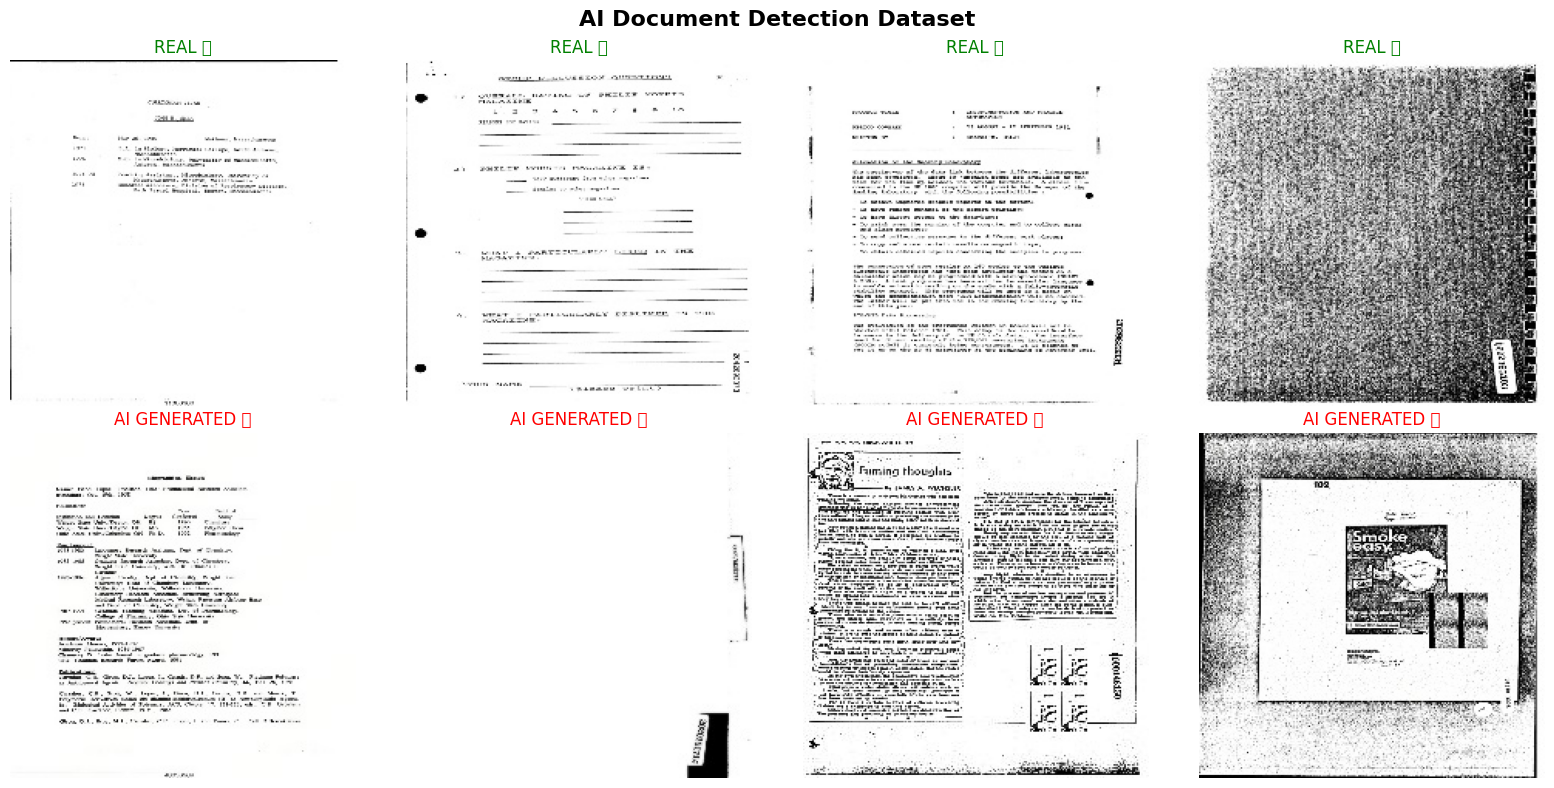

✅ Samples saved!


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

real_imgs = random.sample(os.listdir(REAL_DIR), 4)
ai_imgs   = random.sample(os.listdir(AI_DIR),   4)

for i in range(4):
    r = cv2.imread(os.path.join(REAL_DIR, real_imgs[i]))
    axes[0, i].imshow(cv2.cvtColor(r, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("REAL ✅", color="green", fontsize=12)
    axes[0, i].axis("off")

    a = cv2.imread(os.path.join(AI_DIR, ai_imgs[i]))
    axes[1, i].imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("AI GENERATED ❌", color="red", fontsize=12)
    axes[1, i].axis("off")

plt.suptitle("AI Document Detection Dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/results/samples.png")
plt.show()
print("✅ Samples saved!")

In [5]:
BASE_DIR = "E:/document_forensics/module5_aidetection/module5a_aidoc"
REAL_DIR = f"{BASE_DIR}/dataset/real"
AI_DIR   = f"{BASE_DIR}/dataset/ai_generated"

real_imgs = os.listdir(REAL_DIR)
ai_imgs   = os.listdir(AI_DIR)

random.shuffle(real_imgs)
random.shuffle(ai_imgs)

def split_list(lst):
    n = len(lst)
    return lst[:int(n*0.8)], lst[int(n*0.8):int(n*0.9)], lst[int(n*0.9):]

real_train, real_val, real_test = split_list(real_imgs)
ai_train,   ai_val,   ai_test   = split_list(ai_imgs)

def copy_files(files, src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for f in tqdm(files, desc=f"-> {os.path.basename(dst_dir)}"):
        shutil.copy2(os.path.join(src_dir, f),
                     os.path.join(dst_dir, f))

print("📦 Splitting dataset...")
copy_files(real_train, REAL_DIR, f"{BASE_DIR}/dataset/train/real")
copy_files(real_val,   REAL_DIR, f"{BASE_DIR}/dataset/val/real")
copy_files(real_test,  REAL_DIR, f"{BASE_DIR}/dataset/test/real")
copy_files(ai_train,   AI_DIR,   f"{BASE_DIR}/dataset/train/ai_generated")
copy_files(ai_val,     AI_DIR,   f"{BASE_DIR}/dataset/val/ai_generated")
copy_files(ai_test,    AI_DIR,   f"{BASE_DIR}/dataset/test/ai_generated")

print(f"\n✅ Train -> Real: {len(real_train):,} | AI: {len(ai_train):,}")
print(f"✅ Val   -> Real: {len(real_val):,}   | AI: {len(ai_val):,}")
print(f"✅ Test  -> Real: {len(real_test):,}  | AI: {len(ai_test):,}")

📦 Splitting dataset...


-> ai_generated: 100%|██████████| 10000/10000 [00:04<00:00, 2147.49it/s]


✅ Train -> Real: 80,000 | AI: 80,000
✅ Val   -> Real: 10,000   | AI: 10,000
✅ Test  -> Real: 10,000  | AI: 10,000


In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, random, torch

class AIDocDataset(Dataset):
    def __init__(self, real_dir, ai_dir, transform=None):
        self.transform = transform
        self.images    = []
        self.labels    = []

        for f in os.listdir(real_dir):
            self.images.append(os.path.join(real_dir, f))
            self.labels.append(0)  # 0 = Real

        for f in os.listdir(ai_dir):
            self.images.append(os.path.join(ai_dir, f))
            self.labels.append(1)  # 1 = AI Generated

        combined = list(zip(self.images, self.labels))
        random.shuffle(combined)
        self.images, self.labels = zip(*combined)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

BASE_DIR = "E:/document_forensics/module5_aidetection/module5a_aidoc/dataset"

train_dataset = AIDocDataset(f"{BASE_DIR}/train/real", f"{BASE_DIR}/train/ai_generated", train_transform)
val_dataset   = AIDocDataset(f"{BASE_DIR}/val/real",   f"{BASE_DIR}/val/ai_generated",   val_transform)
test_dataset  = AIDocDataset(f"{BASE_DIR}/test/real",  f"{BASE_DIR}/test/ai_generated",  val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Train samples : {len(train_dataset):,}")
print(f"✅ Val samples   : {len(val_dataset):,}")
print(f"✅ Test samples  : {len(test_dataset):,}")
print(f"✅ Train batches : {len(train_loader):,}")
print(f"🚀 DataLoaders ready!")

✅ Train samples : 160,000
✅ Val samples   : 20,000
✅ Test samples  : 20,000
✅ Train batches : 2,500
🚀 DataLoaders ready!


In [7]:
import timm
import torch.nn as nn

class AIDocDetector(nn.Module):
    def __init__(self):
        super(AIDocDetector, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            num_classes=2
        )
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(self.model.classifier.in_features, 2)
        )

    def forward(self, x):
        return self.model(x)

model     = AIDocDetector().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model      : EfficientNetB3")
print(f"✅ Parameters : {total_params:,}")
print(f"✅ Device     : {device}")
print(f"🚀 AI Doc Detector ready!")

✅ Model      : EfficientNetB3
✅ Parameters : 10,699,306
✅ Device     : cuda
🚀 AI Doc Detector ready!


In [8]:
EPOCHS    = 15
BEST_ACC  = 0.0
MODEL_DIR = "E:/document_forensics/module5_aidetection/module5a_aidoc/models"

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print("🚀 Training AI Document Detector!")
print(f"📊 Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
print("=" * 60)

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in tqdm(train_loader,
                             desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader,
                                 desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    t_loss = train_loss / len(train_loader)
    v_loss = val_loss   / len(val_loader)
    t_acc  = 100. * train_correct / train_total
    v_acc  = 100. * val_correct   / val_total

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    scheduler.step()

    if v_acc > BEST_ACC:
        BEST_ACC = v_acc
        torch.save(model.state_dict(),
                   f"{MODEL_DIR}/best_aidoc_detector.pth")
        saved = "Saved Best!"
    else:
        saved = ""

    print(f"\nEpoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% | "
          f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}% {saved}")
    print("-" * 60)

print(f"\nBest Val Accuracy: {BEST_ACC:.2f}%")

🚀 Training AI Document Detector!
📊 Train: 160,000 | Val: 20,000


Epoch 1/15 [Val]  : 100%|██████████| 313/313 [00:58<00:00,  5.39it/s]



Epoch 01/15 | Train Loss: 0.1461 | Train Acc: 94.33% | Val Loss: 0.0336 | Val Acc: 99.03% Saved Best!
------------------------------------------------------------


Epoch 2/15 [Val]  : 100%|██████████| 313/313 [00:51<00:00,  6.07it/s]



Epoch 02/15 | Train Loss: 0.0796 | Train Acc: 97.29% | Val Loss: 0.0245 | Val Acc: 99.36% Saved Best!
------------------------------------------------------------


...


Epoch 04/15 | Train Loss: 0.0603 | Train Acc: 98.03% | Val Loss: 0.0284 | Val Acc: 99.46% Saved Best!
------------------------------------------------------------


Epoch 5/15 [Val]  : 100%|██████████| 313/313 [00:51<00:00,  6.09it/s]



Epoch 05/15 | Train Loss: 0.0526 | Train Acc: 98.29% | Val Loss: 0.0146 | Val Acc: 99.59% Saved Best!
------------------------------------------------------------


Epoch 6/15 [Train]:   2%|▏         | 56/2500 [00:21<15:45,  2.58it/s]


KeyboardInterrupt: 

In [9]:
MODEL_DIR = "E:/document_forensics/module5_aidetection/module5a_aidoc/models"
model.load_state_dict(torch.load(
    f"{MODEL_DIR}/best_aidoc_detector.pth",
    map_location=device, weights_only=True))
model.eval()

test_correct = 0
test_total   = 0

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs      = model(imgs)
        _, predicted = outputs.max(1)
        test_total  += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100. * test_correct / test_total
print(f"\n{'='*45}")
print(f"🏆 FINAL TEST ACCURACY : {test_acc:.2f}%")
print(f"✅ Total test images   : {test_total:,}")
print(f"✅ Correct             : {test_correct:,}")
print(f"❌ Wrong               : {test_total - test_correct:,}")
print(f"{'='*45}")

Testing: 100%|██████████| 313/313 [00:54<00:00,  5.70it/s]


🏆 FINAL TEST ACCURACY : 99.57%
✅ Total test images   : 20,000
✅ Correct             : 19,914
❌ Wrong               : 86
